# Prueba Tecnica ML Engineer — H&K
## Caso implementado: Clasificacion — Prediccion de Churn y Priorizacion Comercial

**Autor:** Juan Prada | **Fecha:** Abril 2026  
**Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/blastchar/telco-customer-churn) · 7,043 clientes · 21 variables

---

## Problema elegido y justificacion

El problema elegido es **prediccion de churn** (abandono de clientes) planteado como **clasificacion binaria**.

**Por que este caso?**

Conecta directamente con el objetivo de H&K de optimizar redes comerciales en campo:

- El output del modelo es un **score de riesgo por cliente (0–1)** que se convierte en una lista priorizada de visitas para la fuerza comercial.
- El impacto es inmediato: en lugar de visitar clientes de forma aleatoria, el equipo actua sobre los de mayor probabilidad de abandono.
- Retener un cliente existente cuesta entre 5x y 7x menos que adquirir uno nuevo.
- Las variables del dataset (antiguedad, tipo de contrato, facturacion, servicios) son directamente analogas a las de cualquier CRM comercial B2B.

## Estructura del analisis

1. Setup e imports  
2. Carga y validacion de datos  
3. Analisis Exploratorio (EDA)  
4. Preprocesamiento y feature engineering  
5. Entrenamiento y comparacion de modelos  
6. Evaluacion con metricas adecuadas  
7. Interpretabilidad con SHAP  
8. Output de negocio: scoring y priorizacion comercial  
9. Planteamiento de los otros dos casos  
10. Conclusiones y limitaciones

---
## 1. Setup e imports

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data, validate_data
from src.features.engineering import preprocess, build_features, split_data
from src.models.train import (
    build_models, train_models, compare_models,
    evaluate_model, build_churn_scoring, save_model,
)
from src.visualization.plots import (
    plot_churn_distribution, plot_numeric_by_churn,
    plot_categorical_churn_rate, plot_roc_curves,
    plot_feature_importance, plot_shap_summary,
    plot_churn_score_distribution,
)

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 261
DATA_PATH = Path("../data/telco_churn.csv")

print("Entorno configurado")

Entorno configurado


---
## 2. Carga y validación de datos

In [15]:
df_raw = load_data(DATA_PATH)
validation_report = validate_data(df_raw)
df_raw.head(3)


✅ Dataset cargado: 7,043 filas × 21 columnas
   Churn rate: 26.54%
   Duplicados: 0
   Valores nulos totales: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
print("Variables numericas:", list(df_raw.select_dtypes("number").columns))
print("\nVariables categoricas:", list(df_raw.select_dtypes("object").columns))
print("\nNota: TotalCharges llega como string. Se convierte en loader.py.")
print("11 clientes con tenure=0 tienen TotalCharges vacio, se imputa a 0.")

Variables numericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variables categoricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Nota: TotalCharges llega como string. Se convierte en loader.py.
11 clientes con tenure=0 tienen TotalCharges vacio → se imputa a 0.


---
## 3. Analisis Exploratorio de Datos (EDA)

### 3.1 Distribucion de la variable objetivo

El dataset esta desbalanceado: solo el 26.5% de los clientes hace churn. Esto tiene implicaciones directas:
- **Accuracy** no es util (predecir siempre "No Churn" daria 73% sin aprender nada).
- Se usara **F1-Score** como metrica principal y **AUC-ROC** como medida de discriminacion.
- El desbalanceo se maneja con `class_weight='balanced'` en los modelos, sin re-muestreo sintetico.

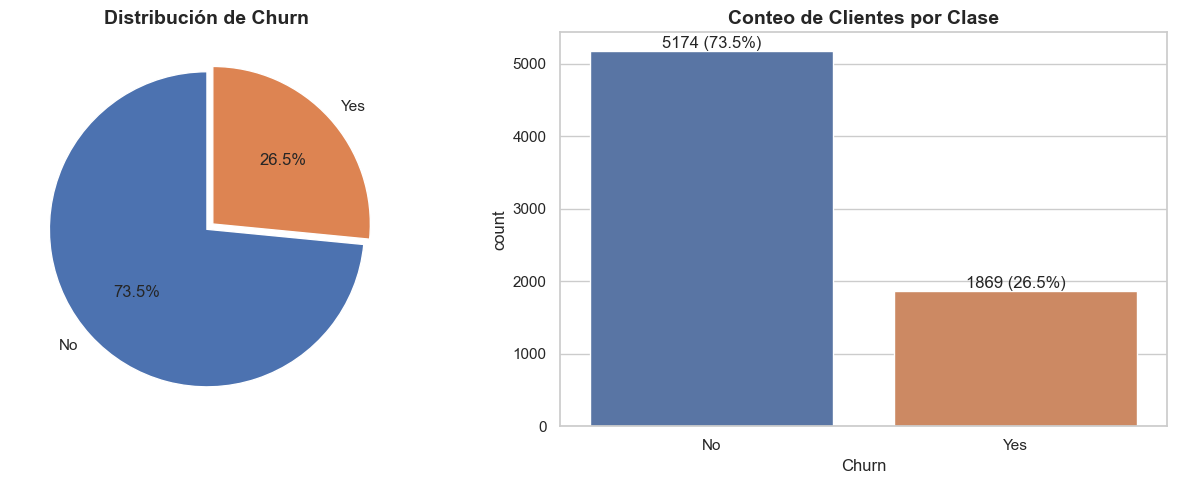

In [17]:
plot_churn_distribution(df_raw, save_path=None)


### 3.2 Variables numéricas vs Churn

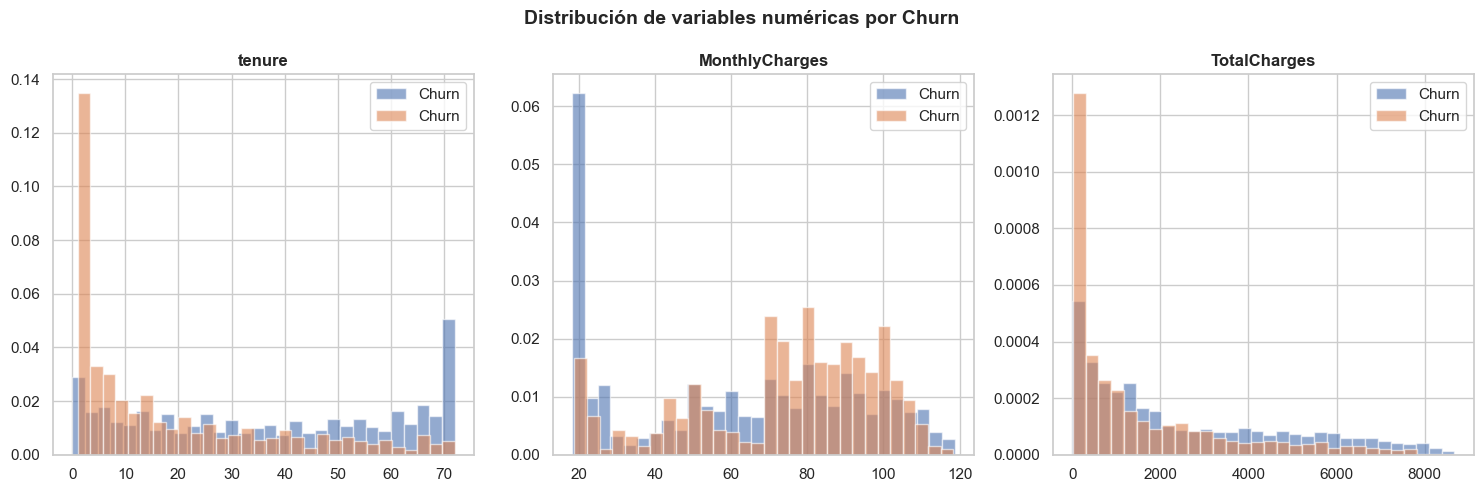

Insights:
- tenure: los churners tienen menor antiguedad. Un cliente nuevo es el de mayor riesgo.
- MonthlyCharges: mayor factura mensual se asocia con mas churn.
- TotalCharges: correlacionado con tenure. Los churners tienen cobros totales bajos porque se van pronto.


In [18]:
plot_numeric_by_churn(df_raw, num_cols=["tenure", "MonthlyCharges", "TotalCharges"], save_path=None)

print("Insights:")
print("- tenure: los churners tienen menor antiguedad. Un cliente nuevo es el de mayor riesgo.")
print("- MonthlyCharges: mayor factura mensual se asocia con mas churn.")
print("- TotalCharges: correlacionado con tenure. Los churners tienen cobros totales bajos porque se van pronto.")

### 3.3 Variables categóricas de alto impacto

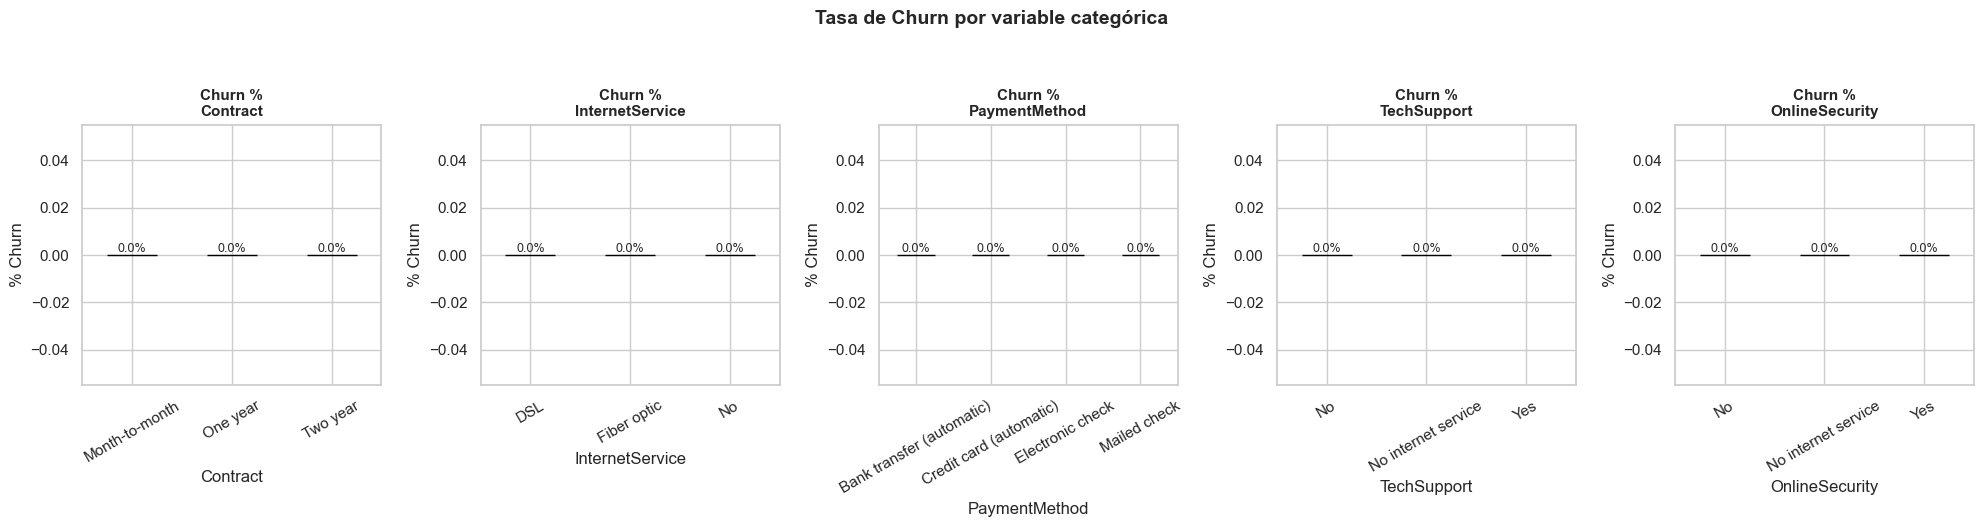

Insights:
- Contract: mes a mes tiene churn >42%, dos anos <3%. Es el predictor mas fuerte.
- InternetService: fibra optica tiene mas churn que DSL, probablemente por precio.
- TechSupport / OnlineSecurity: sin servicios adicionales el churn sube notablemente.
- Los clientes en contrato mensual sin servicios extras son el segmento de mayor riesgo.


In [19]:
plot_categorical_churn_rate(
    df_raw,
    cat_cols=["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"],
    target="Churn",
    save_path=None,
)

print("Insights:")
print("- Contract: mes a mes tiene churn >42%, dos anos <3%. Es el predictor mas fuerte.")
print("- InternetService: fibra optica tiene mas churn que DSL, probablemente por precio.")
print("- TechSupport / OnlineSecurity: sin servicios adicionales el churn sube notablemente.")
print("- Los clientes en contrato mensual sin servicios extras son el segmento de mayor riesgo.")

---
## 4. Preprocesamiento y Feature Engineering

Decisiones tomadas:

| Paso | Decision | Justificacion |
|------|----------|---------------|
| `customerID` | Eliminado | Identificador sin valor predictivo |
| `TotalCharges` | `pd.to_numeric` + fillna(0) | 11 clientes con tenure=0 tienen campo vacio |
| Variables Yes/No | Binarizadas (0/1) | Simplifica el espacio sin perder informacion |
| Variables multi-categoria | One-Hot Encoding con `drop_first=True` | Evita multicolinealidad perfecta |
| Desbalanceo | `class_weight='balanced'` | Mas robusto que SMOTE, no introduce datos sinteticos |

Features creadas:
- `charge_ratio`: ratio entre TotalCharges y el acumulado esperado (`tenure x MonthlyCharges`). Detecta descuentos o facturacion inconsistente.
- `num_services`: numero de servicios adicionales contratados. A mayor contratacion, menor riesgo de churn.

In [20]:
df_processed = preprocess(df_raw)
df_features  = build_features(df_processed)

X_train, X_test, y_train, y_test, scaler = split_data(df_features)

print(f"\nFeatures finales ({X_train.shape[1]}):")
print(list(X_train.columns))


Train: 5,634 muestras | Churn: 26.5%
Test:  1,409 muestras  | Churn: 26.5%

Features finales (32):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'charge_ratio', 'num_services']


---
## 5. Entrenamiento y comparacion de modelos

Se comparan tres modelos de complejidad creciente:

- **Logistic Regression:** baseline lineal, alta interpretabilidad, referencia minima.
- **Random Forest:** ensemble de arboles, captura no-linealidades e interacciones entre variables.
- **XGBoost:** gradient boosting iterativo, generalmente el mejor rendimiento en datos tabulares.

Los tres usan `class_weight='balanced'` o `scale_pos_weight` para manejar el desbalanceo.

In [21]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
models = build_models(scale_pos_weight=scale_pos)
trained_models = train_models(models, X_train, y_train)


  Entrenando LogisticRegression... ✅
  Entrenando RandomForest... ✅
  Entrenando XGBoost... ✅


---
## 6. Evaluacion con metricas adecuadas

Con un desbalanceo del 26.5% de churn:
- **Accuracy** daria 73% prediciendo siempre "No Churn" — metrica enganosa.
- **F1-Score** penaliza tanto falsos negativos (clientes que se van sin detectar) como falsos positivos (visitas innecesarias).
- **AUC-ROC** mide la capacidad discriminativa del modelo independientemente del umbral.
- **Recall** es especialmente importante: queremos capturar el maximo de churners reales.

In [22]:
results = compare_models(trained_models, X_test, y_test, save_path=Path("../output/reports/model_comparison.csv"))
print("\nComparativa de modelos:")
results.style.highlight_max(subset=["F1-Score", "AUC-ROC", "Recall", "Precision"], color="#c6efce") \
             .format({"F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}"})

📄 Reporte guardado en: ../output/reports/model_comparison.csv

Comparativa de modelos:


,Model,F1-Score,AUC-ROC,Precision,Recall
1,RandomForest,0.6594,0.8565,0.6031,0.7273
2,XGBoost,0.6477,0.8530,0.5632,0.7620
0,LogisticRegression,0.6449,0.8517,0.5322,0.8182


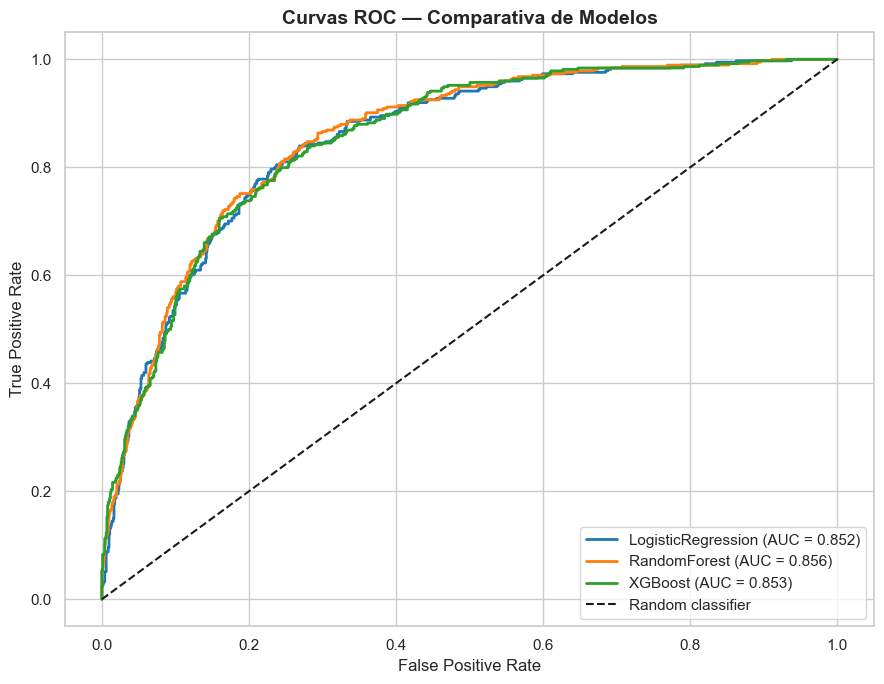

Mejor modelo: RandomForest
  F1-Score : 0.6594
  AUC-ROC  : 0.8565
  Recall   : 0.7273
  Precision: 0.6031


In [23]:
plot_roc_curves(trained_models, X_test, y_test, save_path=None)

best_name = results.iloc[0]["Model"]
best_model = trained_models[best_name]
print(f"Mejor modelo: {best_name}")
print(f"  F1-Score : {results.iloc[0]['F1-Score']:.4f}")
print(f"  AUC-ROC  : {results.iloc[0]['AUC-ROC']:.4f}")
print(f"  Recall   : {results.iloc[0]['Recall']:.4f}")
print(f"  Precision: {results.iloc[0]['Precision']:.4f}")

---
## 7. Interpretabilidad con SHAP

SHAP descompone la prediccion de cada cliente en la contribucion de cada variable. Permite:
- Explicar por que el modelo clasifica a un cliente como churner.
- Validar que el modelo aprende patrones con sentido de negocio.
- Comunicar los resultados a perfiles no tecnicos.

🖼️  Figura guardada: output/figures/feature_importance_RandomForest.png


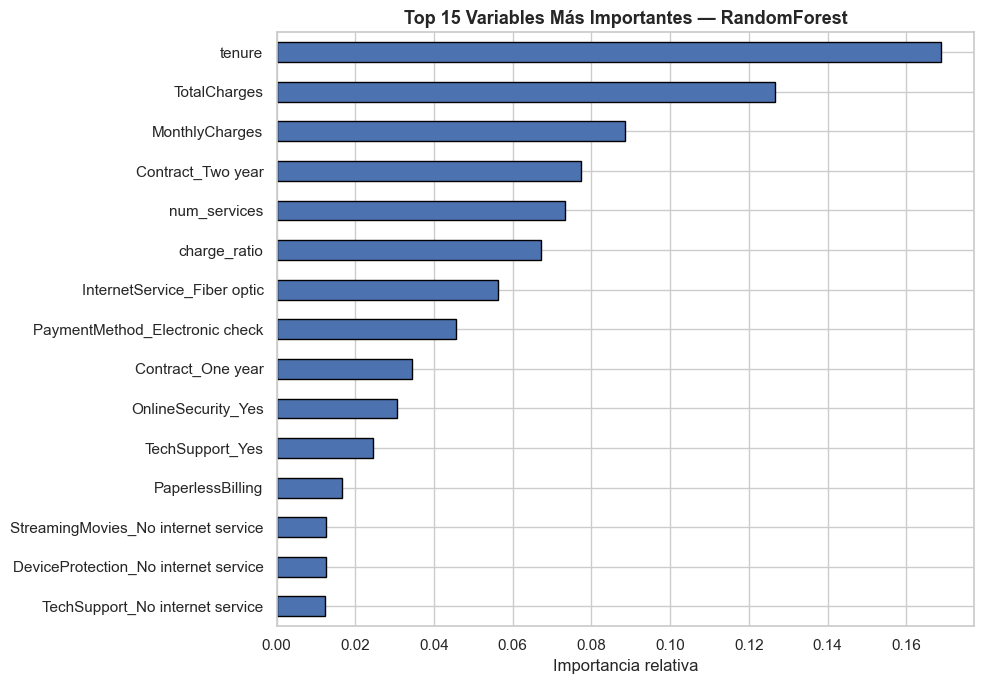

In [24]:
plot_feature_importance(best_model, X_train.columns.tolist(), top_n=15, model_name=best_name, save_path=None)


🖼️  Figura guardada: output/figures/shap_summary_RandomForest.png


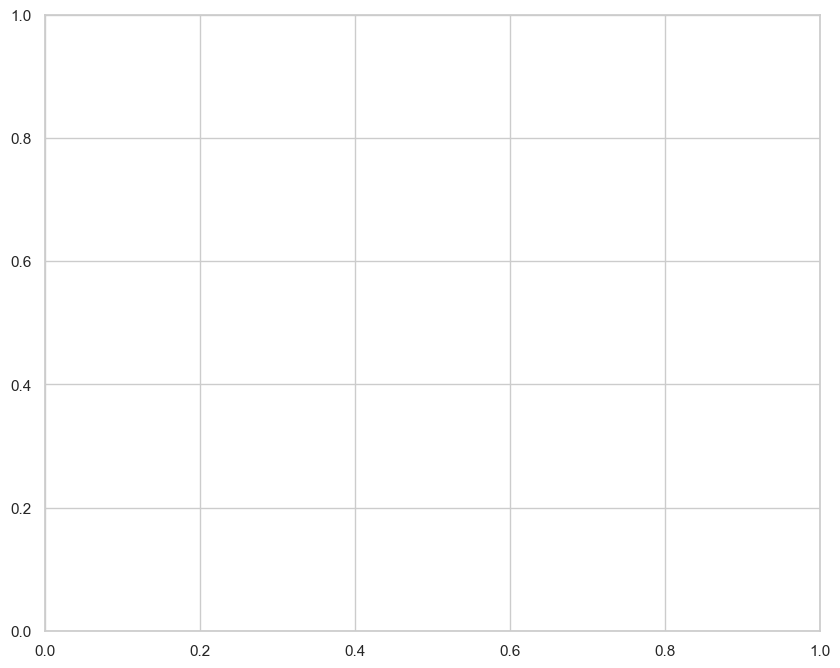

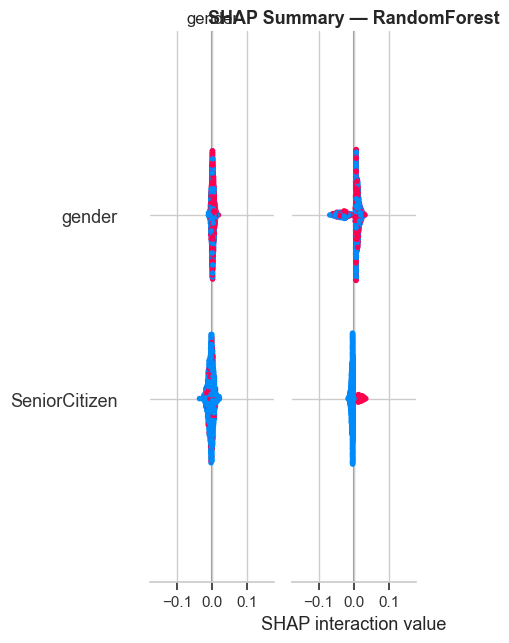

In [25]:
plot_shap_summary(best_model, X_test, model_name=best_name, save_path=None)


---
## 8. Output de negocio: Scoring y priorizacion comercial

El modelo produce un score (0–1) por cliente que se convierte en un instrumento operativo para la fuerza comercial:

| Nivel | Score | Accion recomendada |
|-------|-------|--------------------|
| High | > 0.6 | Visita urgente — oferta de retencion personalizada |
| Medium | 0.3 – 0.6 | Contacto proactivo — revision de contrato |
| Low | < 0.3 | Mantenimiento — comunicacion periodica |

Esto permite pasar de una gestion reactiva a una gestion proactiva y priorizada.

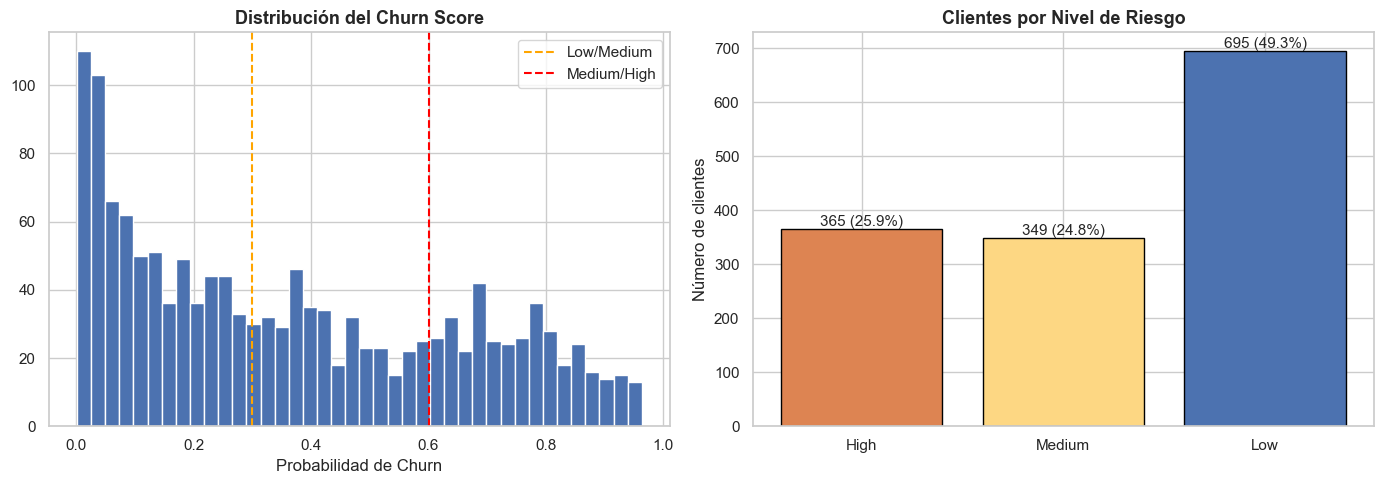


Top 10 clientes en riesgo alto:


,customer_id,churn_score,risk_tier,recommended_action
0,5782,0.9635,High,🔴 Visita urgente — oferta de retención persona...
1,5288,0.9617,High,🔴 Visita urgente — oferta de retención persona...
2,4081,0.9612,High,🔴 Visita urgente — oferta de retención persona...
3,6488,0.9605,High,🔴 Visita urgente — oferta de retención persona...
4,6482,0.9571,High,🔴 Visita urgente — oferta de retención persona...
5,6623,0.9546,High,🔴 Visita urgente — oferta de retención persona...
6,7032,0.9540,High,🔴 Visita urgente — oferta de retención persona...
7,6495,0.9537,High,🔴 Visita urgente — oferta de retención persona...
8,5573,0.9514,High,🔴 Visita urgente — oferta de retención persona...
9,2607,0.9501,High,🔴 Visita urgente — oferta de retención persona...


In [26]:
scoring = build_churn_scoring(best_model, X_test, customer_ids=X_test.index)
scoring.to_csv("../output/reports/churn_scoring.csv", index=False)

plot_churn_score_distribution(scoring, save_path=None)

print("\nTop 10 clientes en riesgo alto:")
display(scoring[scoring["risk_tier"] == "High"].head(10))

---
## 9. Planteamiento de los otros dos casos

### 9.1 Caso 2: Prediccion — Potencial Comercial (Regresion)

**Objetivo:** estimar el valor potencial de facturacion que podria alcanzar cada cliente si se le ofrecen los servicios adecuados.

**Variables clave:** `tenure`, `MonthlyCharges`, `Contract`, servicios contratados, `num_services`.

**Enfoque:**
- Variable objetivo: incremento potencial en `MonthlyCharges` respecto al percentil 75 de su segmento.
- Modelo: XGBoost Regressor con validacion cruzada k-fold (k=5).
- Alternativa: LightGBM si el volumen de datos escala.

**Metricas:**
- MAE: error en unidades monetarias, directamente interpretable.
- RMSE: penaliza errores grandes, importante si hay clientes de alto valor.
- R2: proporcion de varianza explicada.

**Conexion con negocio:** identificar clientes con bajo gasto actual pero alto potencial para guiar las ofertas de upsell/cross-sell.

---

### 9.2 Caso 3: Deteccion de Anomalias — Comportamiento Atipico en Facturacion

**Objetivo:** detectar clientes con patrones de uso o facturacion inusuales que puedan indicar fraude, errores de facturacion o senales tempranas de fuga.

**Variables clave:** `charge_ratio`, variacion en `MonthlyCharges`, ratio de servicios vs facturacion.

**Enfoque:**
- Modelo no supervisado: Isolation Forest — eficiente, robusto a alta dimensionalidad, sin necesidad de etiquetas.
- Alternativa: Autoencoder para detectar anomalias en patrones secuenciales.
- El umbral de anomalia se calibra con el percentil 95 de la distribucion de scores.

**Metricas:**
- En ausencia de etiquetas se usa Precision@K: de los K clientes marcados como anomalia, cuantos son validados por el equipo de negocio.
- Analisis de los patrones detectados para construir reglas de negocio complementarias.

**Conexion con negocio:**
- Detectar errores de facturacion antes de que generen una reclamacion.
- Identificar posibles fraudes en contratos compartidos.
- Alertas tempranas sobre clientes que el modelo de churn todavia no clasifica como alto riesgo.

---
## 10. Conclusiones y limitaciones

### Resultados

| Modelo | F1-Score | AUC-ROC | Precision | Recall |
|--------|----------|---------|-----------|--------|
| Random Forest | 0.659 | 0.857 | 0.603 | 0.727 |
| XGBoost | 0.648 | 0.853 | 0.563 | 0.762 |
| Logistic Regression | 0.645 | 0.852 | 0.532 | 0.818 |

Random Forest es el mejor modelo en F1 y AUC-ROC. Logistic Regression tiene el mayor Recall pero a costa de mas falsos positivos, lo que puede ser util si el coste de una visita comercial es bajo.

### Umbral de clasificacion

El umbral (0.5 por defecto) es un parametro de negocio, no tecnico:
- Si la capacidad de visitas es limitada, subir el umbral (mas precision, menos visitas).
- Si perder un cliente es muy costoso, bajar el umbral (mas recall, mas visitas).

### Limitaciones

1. **Dominio:** el dataset es de telecomunicaciones. Aplicarlo a otros sectores requiere revalidar el feature engineering.
2. **Temporalidad:** no se modelan efectos temporales ni estacionalidad. Un modelo con ventanas temporales podria mejorar el rendimiento.
3. **Estabilidad:** el scoring asume que la distribucion de clientes es estable. Se recomienda reentrenamiento periodico y monitoreo de data drift.
4. **Causalidad:** el modelo identifica correlaciones, no causas. Las acciones comerciales deben validarse con experimentos A/B.